Suppose a single quantum is emitted at the site where the open quantum system is coupled:

In [1]:
import numpy as np
import lightcones.linalg as la
from lightcones.solvers.schrodinger import solve
import matplotlib.pyplot as plt

# use latex for plotting
# requires installed latex 
# comment if do not need it 

plt.rcParams['text.usetex'] = True

In [2]:
n_sites = 100
# on-site energies
es = [1]*n_sites
# hoppings
hs = [0.05]*(n_sites-1)
H = la.tridiag(es, hs)

tmax = 800
dt = 0.01
t = np.arange(start = 0, stop = tmax, step = dt)
nt = t.size

phi_0 = np.zeros(n_sites, dtype = complex)
phi_0[0] = 1 # initially quantum is on the site 0

phi_lc = np.zeros((n_sites, nt), dtype = np.cdouble) # Here we store the propagated orbitals

def apply_h(ti, phi_in, phi_out):
    la.mv(H, phi_in, phi_out, cout=1)

def eval_o(ti, phi):
    phi_lc[:, ti] = phi
    
solve(0, nt-1, dt, apply_h, phi_0, eval_o = eval_o)

In [3]:
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import FuncAnimation,  PillowWriter

psi_grid = phi_lc[:, ::1000]
x = range(n_sites)
t_ = t[::1000]

def update_fi(frame, line, x):
    line.set_ydata( np.abs(psi_grid[:, frame]))
    return [line]
    
fig, ax = plt.subplots()
ax.set_xlabel("chain site $k$")
ax.set_ylabel("");
y = np.abs(psi_grid[:, 0])**2
    
line, = ax.plot(x, y)

nt_ = len(t_)
    
time = np.arange(0, nt_, 1)

animation = FuncAnimation(
    fig,                
    func=update_fi,    
    frames=time,       
    fargs=(line, x),    
    interval=30,       
    blit=True,         
    repeat=True)       

from IPython.display import HTML
display(HTML(animation.to_jshtml()))
plt.close()

writer = PillowWriter(fps=15, metadata=dict(artist='YourName'), bitrate=1800)
animation.save('emitted_wavepacket.gif', writer=writer)

Let us plot the wavepacket at the last time moment:

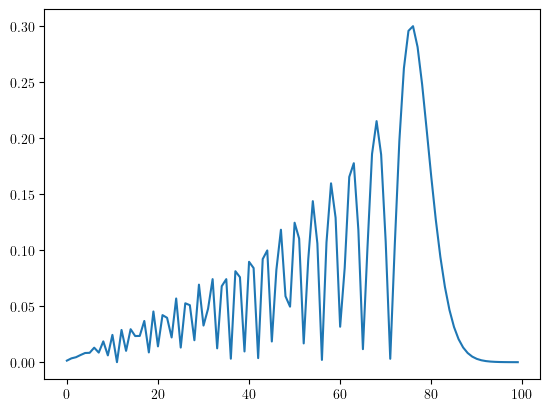

In [4]:
x = range(n_sites)
plt.plot(x, np.abs(phi_lc[:, -1]))

From the plot above we see that the wavepacket has well-defined forward front. The highest peak position $vt$ moves with some constant velocity $v$, and belyond the front it decays in an exponential way, so that the Lieb-Robinson bound is valid:
$\alpha_k\left(t\right) \leq const \times exp\left(vt - k\right)$.
However we see that there is no backward front: the wavepacket decays slowly in an algebaic way. 
This absence of the backward front is the main reason why the real-time quench problem is difficult

Below we plot $\alpha_0\left(t\right)$ which is the amplitude to observe the quantum on chain site $0$ after $t$ units of time after emission. In other words, this is the amplitude for the quantum to return to the source after $t$ units of time.

(0.0, 300.0)

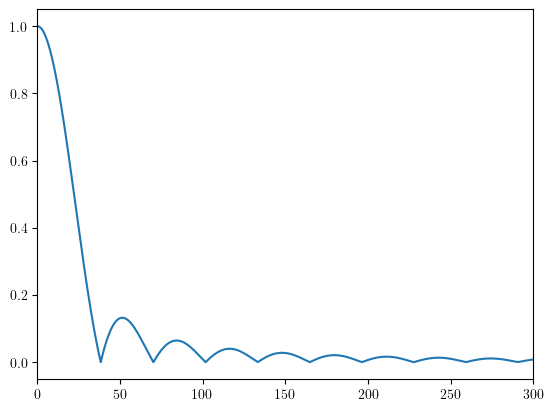

In [5]:
plt.plot(t, np.abs(phi_lc[0, :]))
plt.xlim(0, 300)

We see that the amplitude for the quantum to return is a slowly decaying algebraic function. That is, the emitted quanta decouple very slowly.

We provide solution to this problem. We find a moving frame such that the emitted quanta decouple exponentially fast in time:

In [7]:
import lightcones as lc

# spread
spread = lc.metric.spread(es, hs, nt, dt)

# rho_plus
rho_plus = lc.metric.rho_plus(spread, dt)

# minimal light cone
rtol = 10**(-6)
ti_arrival, spread_min, U_min, rho_plus_min = lc.frames.minimal_forward(spread, rho_plus, dt, rtol)

# causal diamond frame
cd_dim = 7
spread_cd, U_cd = lc.frames.causal_diamonds.fixed(spread_min, ti_arrival, U_min, rho_plus_min, dt, rtol, cd_dim)

# moving frame
spread_mv, H_mv = lc.frames.causal_diamonds.moving(spread_cd, ti_arrival, U_cd, dt, cd_dim)

(0.0, 300.0)

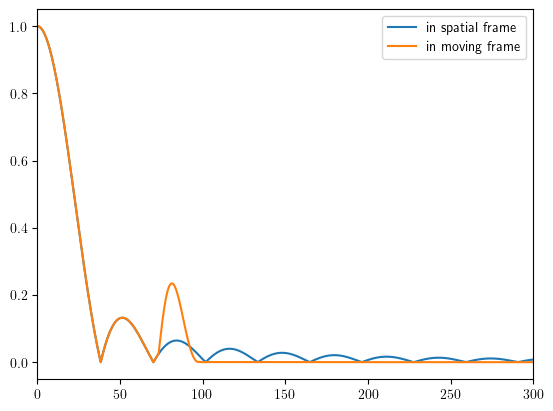

In [8]:
plt.plot(t, np.abs(phi_lc[0, :]), label = 'in spatial frame')
plt.plot(t, np.abs(spread_mv[0, :]), label = 'in moving frame')
plt.legend()
plt.xlim(0, 300)

Let us also see how the emitted wavepacket propagates in the moving frame:

In [9]:
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import FuncAnimation,  PillowWriter

psi_grid = spread_mv[:, ::1000]
x = range(n_sites)
t_ = t[::1000]

def update_fi(frame, line, x):
    line.set_ydata( np.abs(psi_grid[:, frame]))
    return [line]
    
fig, ax = plt.subplots()
ax.set_xlabel("chain site $k$")
ax.set_ylabel("");
y = np.abs(psi_grid[:, 0])**2
    
line, = ax.plot(x, y)

nt_ = len(t_)
    
time = np.arange(0, nt_, 1)

animation = FuncAnimation(
    fig,                
    func=update_fi,    
    frames=time,       
    fargs=(line, x),    
    interval=30,       
    blit=True,         
    repeat=True)       

from IPython.display import HTML
display(HTML(animation.to_jshtml()))
plt.close()

writer = PillowWriter(fps=15, metadata=dict(artist='YourName'), bitrate=1800)
animation.save('emitted_wavepacket_mv.gif', writer=writer)

We obbserve that this wavepacket has not only forward front, but also the backward front! The "sites" (modes) in the moving frame which escape the backward front are irreversibly decoupled from the open quantum system.

Here we plot the wavepacket in the moving frame at the final time:

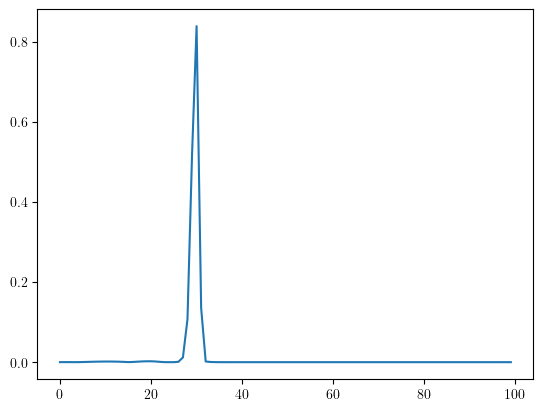

In [10]:
plt.plot(x, np.abs(spread_mv[:, -1]))

We rewrite the Schrodinger equation in the moving frame, and then solve the many-body quantum quench problem in this moving frame.